# PCA on subclasses

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

In [2]:
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_PCA_subclass.xlsx"
total = pd.read_excel(dataset_total_path)

# Define dataset : metabolite class

In [3]:
subclass = "Phenylpropanoids"
level = 'First'

df = total.set_index('Class')
mask = df.loc[level] == subclass
df = df.loc[:, mask]
df = df.reset_index()
df.head()

df = df.iloc[3:]
df.head()

,Class,Nobiletin,Sinensetin,O-Feruloylgalactarate,3-Coumaric acid,Vicenin II,Hesperidin,Tangeritin,5-O-Demethylnobiletin,Ferulic acid,...,Nevadensin 7-rutinoside,Spinosin,Kaempferol 3-(3''-acetyl-alpha-L-arabinofuranoside)-7-rhamnoside,Rhamnazin 3-[6''-(3-hydroxy-3-methylglutaryl)glucoside],Riccionidin A,Medicarpin 3-O-glucoside-6'-malonate,Naringin 4'-glucoside,Luteolin 7-(6''-p-benzoyglucoside),"Quercetin 3,3'-dimethyl ether 7-rutinoside",Myricetin
3,LN,2720065.744721,1839025.453052,992607565.592413,1938863576.68462,222102735.726222,2181985.63257,1440814.528566,1176319.148324,1064170667.05225,...,3301826.688899,806010.158435,1366977.730216,95778.474108,6211581.439848,5182388.641948,2529766.73279,5501052.033708,603634.684841,646645.965946
4,LN,1499595.204022,967917.509709,743418655.146411,1874431029.18653,192805427.905135,2474049.087489,533360.657443,274839.840217,1050387814.92255,...,3005300.027967,456050.770081,1163637.448139,151720.092528,5655136.955902,5483432.445099,2375269.297113,4969555.17634,341680.086861,649227.916792
5,LN,938126.279501,499723.742387,1082869490.26418,2224746678.38767,216677274.515516,1156792.713173,982343.223174,654486.517896,1251797193.80395,...,3415805.450637,1099762.52607,1660268.286339,89605.889174,5967540.698202,5908915.491491,3091317.58587,4738249.701534,415683.891141,582083.387085
6,LN,5672215.051321,2159848.457903,1100139141.07418,2156118650.87831,206594365.014861,1469601.143586,3130246.179487,2264926.267594,1230148412.75667,...,3772249.371609,942379.674297,1258800.059291,95471.538299,5170633.660392,6271526.656636,3191487.622715,4258503.4662,504653.332858,692230.800378
7,LN,1018462.867837,693349.491182,772172351.359666,2045342903.08634,157030558.926409,2240545.193335,878431.026569,616319.65618,1077155826.1141,...,4021912.161609,843148.832798,1115378.183612,99355.250954,6209051.78336,5266339.072768,2986844.911095,3209616.066083,320840.072545,595287.260275


In [4]:
print(df.shape)
df['Class'].value_counts()

(24, 146)


Class
LN    6
LP    6
SN    6
SP    6
Name: count, dtype: int64

In [5]:
cols_to_convert = df.columns[1:]
df[cols_to_convert] = df[cols_to_convert].astype(float)

In [6]:
def encodage(df):
    code = {
    'LP' : 'Lemon inoculated',
    'SP' : 'Orange inoculated',
    'LN' : 'Lemon control',
    'SN' : 'Orange control'
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df

def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [7]:
X, y = preprocessing(df)
# Principalement encoder les classes

Class
Lemon control        6
Lemon inoculated     6
Orange control       6
Orange inoculated    6
Name: count, dtype: int64


In [8]:
import numpy as np
from matplotlib.patches import Ellipse

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    # Remove accidental duplicates from kwargs
    kwargs.pop("n_std", None)
    kwargs.pop("confidence", None)

    x = np.asarray(x)
    y = np.asarray(y)

    if x.size < 2:
        return

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    mean_x, mean_y = x.mean(), y.mean()
    ell = Ellipse(
        (mean_x, mean_y),
        width=width,
        height=height,
        angle=theta,
        fill=False,
        **kwargs
    )
    ax.add_patch(ell)
    return ell

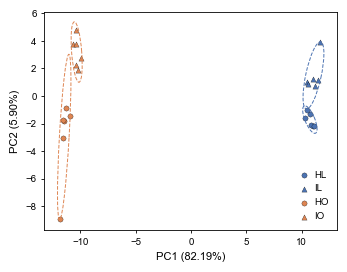

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# --------------------------------------------------
# GLOBAL GRAPHIC PARAMETERS (Single column optimized)
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,              # base text
    "axes.labelsize": 8,         # PC1 / PC2
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# --------------------------------------------------
# PCA PIPELINE
# --------------------------------------------------
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))

model = make_pipeline(
    log2_transformer,
    StandardScaler(),
    PCA(n_components=2)
)

X_reduced = model.fit_transform(X)
pca = model.named_steps['pca']

# --------------------------------------------------
# FIGURE SIZE (85 mm width)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(3.35, 2.6))

# --------------------------------------------------
# VISUAL ENCODING
# --------------------------------------------------
color_map = {
    "Lemon control": "#4c73b2",
    "Lemon inoculated": "#4c73b2",
    "Orange control": "#de8552",
    "Orange inoculated": "#de8552"
}

marker_map = {
    "Lemon control": "o",
    "Orange control": "o",
    "Lemon inoculated": "^",
    "Orange inoculated": "^"
}

label_map = {
    "Lemon control": "HL",
    "Lemon inoculated": "IL",
    "Orange control": "HO",
    "Orange inoculated": "IO"
}

classes = sorted(y.unique())

# --------------------------------------------------
# SCATTER + ELLIPSES
# --------------------------------------------------
for cls in classes:

    mask = (y == cls)
    xg = X_reduced[mask, 0]
    yg = X_reduced[mask, 1]

    ax.scatter(
        xg,
        yg,
        color=color_map[cls],
        marker=marker_map[cls],
        label=label_map[cls],
        s=14,                # ↓ réduit
        edgecolor="black",
        linewidth=0.2        # ↓ plus fin
    )
    
    confidence_ellipse(
        xg,
        yg,
        ax,
        n_std=2.0,
        edgecolor=color_map[cls],
        linewidth=0.7,       # ↓ plus fin
        linestyle="--",
        alpha=1
    )

# --------------------------------------------------
# AXES
# --------------------------------------------------
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)

ax.tick_params(direction='out', length=2, width=0.6)

# --------------------------------------------------
# LEGEND
# --------------------------------------------------
leg = ax.legend(
    frameon=False,
    loc="best",
    handlelength=1.2,
    handletextpad=0.4
)

# --------------------------------------------------
# LAYOUT
# --------------------------------------------------
plt.tight_layout(pad=0.4)

# --------------------------------------------------
# EXPORT
# --------------------------------------------------

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/PCA/PCA_PP.pdf",
    bbox_inches="tight",
    transparent=True
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/PCA/PCA_PP.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [10]:
stop

NameError: name 'stop' is not defined

# Analyse loadings

In [ ]:
# Get metrics from PCA
pca = model.named_steps['pca'] #Identifier le modèle depuis le pipeline
pca.components_.shape

In [ ]:
#Identifier la var expliquée component par component
print(np.cumsum(pca.explained_variance_ratio_))
print(f'Number of components explaining 99% : {np.argmax(np.cumsum(pca.explained_variance_ratio_) > 0.99)}')

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,          # transpose so each row = feature
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns             # variable names
)
print(loadings.head())

for i in range(pca.n_components_):
    print(f"\nTop features in PC{i+1}:")
    print(loadings.iloc[:, i].abs().sort_values(ascending=False).head(10))

# Plot loadings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from matplotlib.patches import FancyArrowPatch

# -------------------------
# 1. PCA pipeline
# -------------------------
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))

model = make_pipeline(
    log2_transformer,
    StandardScaler(),
    PCA(n_components=2)
)

X_reduced = model.fit_transform(X)
pca = model.named_steps["pca"]

# -------------------------
# 2. Extract RAW loadings
# -------------------------
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

# Raw eigenvector coefficients (NOT correlations)
raw_loadings = pca.components_.T[:, :2]

load_df = pd.DataFrame(
    raw_loadings,
    index=feature_names,
    columns=["PC1", "PC2"]
)

# -------------------------
# 3. Select top N metabolites (PC1+PC2 contribution)
# -------------------------
top_n = 30
strength = np.sqrt(load_df["PC1"]**2 + load_df["PC2"]**2)
top = load_df.loc[strength.sort_values(ascending=False).head(top_n).index]

# -------------------------
# 4. Plot raw loading arrows
# -------------------------
fig, ax = plt.subplots(figsize=(12, 10))

for name, row in top.iterrows():
    arrow = FancyArrowPatch(
        (0, 0),
        (row["PC1"], row["PC2"]),
        arrowstyle='-|>',
        linewidth=0.6,
        mutation_scale=12,
        color="black",
        alpha=0.8
    )
    ax.add_patch(arrow)

    ax.text(
        row["PC1"] * 1.08,
        row["PC2"] * 1.08,
        name,
        fontsize=10,
        ha="center",
        va="center"
    )

# -------------------------
# 5. Axis formatting
# -------------------------
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

ax.set_title(f"Raw PCA loadings (top {top_n})", fontsize=16, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.4)
ax.margins(0.2)

plt.tight_layout()

plt.savefig(f"C:/Users/tamer/Documents/PhD/ML/PCA/{subclass}PCA_loading.png", dpi=600, bbox_inches="tight")    

plt.show()
